In [78]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [79]:
train_path = r"C:\Users\Hare kant jha\OneDrive\Desktop\New folder (3)\data\train_images"
test_path = r"C:\Users\Hare kant jha\OneDrive\Desktop\New folder (3)\data\test_images"

print("Train Images:", len(os.listdir(train_path)))
print("Test Images:", len(os.listdir(test_path)))

Train Images: 20000
Test Images: 5000


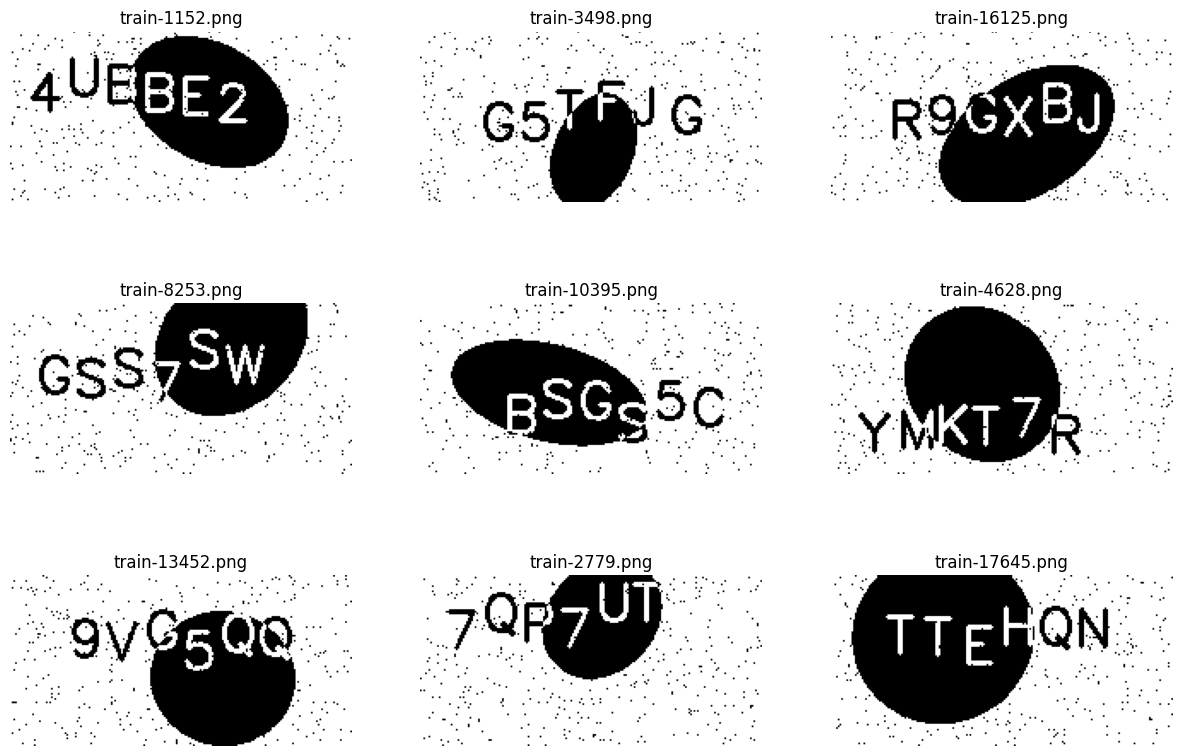

In [80]:
import random

files = os.listdir(train_path)

plt.figure(figsize=(15,10))

for i in range(9):
    img_name = random.choice(files)

    img = cv2.imread(
        os.path.join(train_path,img_name),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(3,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [81]:
for i in range(20):
    img_name = random.choice(files)

    img = cv2.imread(
        os.path.join(train_path,img_name),
        cv2.IMREAD_GRAYSCALE
    )

    print(img.shape)

(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)


In [82]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hare kant jha\OneDrive\Desktop\New folder (3)\data\train-labels.csv")

print("Number of samples:", len(df))

Number of samples: 20000


In [83]:
df["length"] = df["text"].apply(len)

print(df["length"].value_counts())

length
6    19998
8        1
9        1
Name: count, dtype: int64


In [84]:
all_chars = set()

for text in df["text"]:
    all_chars.update(text)

print(sorted(all_chars))
print("Total characters:", len(all_chars))

['+', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'r']
Total characters: 38


In [85]:
allowed = set("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

bad_rows = []

for idx, text in enumerate(df["text"]):
    if any(ch not in allowed for ch in text):
        bad_rows.append(df.iloc[idx])

print(pd.DataFrame(bad_rows))

      Unnamed: 0           image       text  length
2184        2184  train-2184.png   5.40E+12       8
6819        6819  train-6819.png  04-Mar-54       9


In [86]:
df.iloc[[2184, 6819]]

,Unnamed: 0,image,text,length
2184,2184,train-2184.png,5.40E+12,8
6819,6819,train-6819.png,04-Mar-54,9


these two seems unusual and currupted seems spreadsheet-converted labels 

but first let me check test data 

In [87]:
test_files = os.listdir(test_path)

for i in range(10):
    img = cv2.imread(
        os.path.join(test_path, test_files[i]),
        cv2.IMREAD_GRAYSCALE
    )
    print(img.shape)

(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)
(100, 200)


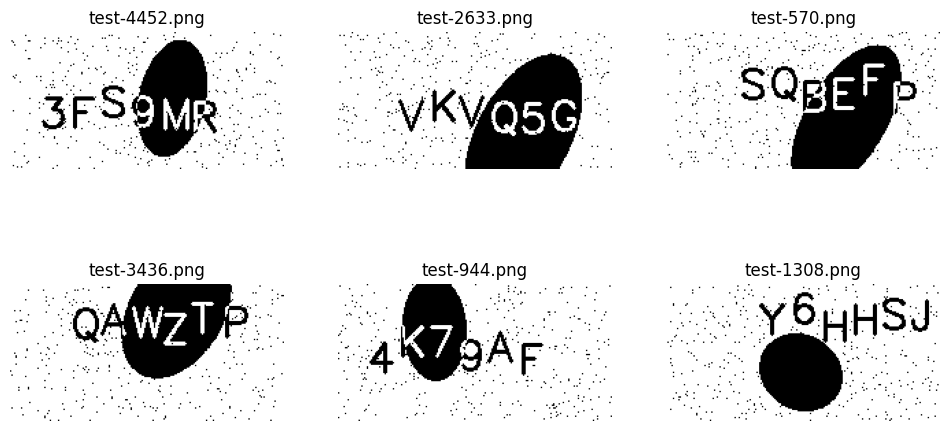

In [88]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(12,6))

for i in range(6):
    img_name = random.choice(test_files)

    img = cv2.imread(
        os.path.join(test_path, img_name),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap="gray")
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [89]:
bad_rows = df[df["length"] != 6]
print(bad_rows)

      Unnamed: 0           image       text  length
2184        2184  train-2184.png   5.40E+12       8
6819        6819  train-6819.png  04-Mar-54       9


In [90]:
allowed = set("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ")

df = df[
    df["text"].apply(
        lambda x: len(str(x)) == 6
        and all(ch in allowed for ch in str(x))
    )
].reset_index(drop=True)

print(len(df))

19998


In [91]:
all_chars = sorted(
    set("".join(df["text"]))
)

print(all_chars)
print("Vocabulary Size:", len(all_chars))

['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Vocabulary Size: 31


In [92]:
vocab = sorted(set("".join(df["text"])))

char_to_idx = {
    char: idx + 1
    for idx, char in enumerate(vocab)
}

idx_to_char = {
    idx + 1: char
    for idx, char in enumerate(vocab)
}

print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


In [93]:
sample = "YV2C3D"

encoded = [
    char_to_idx[ch]
    for ch in sample
]

print(encoded)

[30, 27, 1, 11, 2, 12]


In [94]:
decoded = "".join(
    idx_to_char[i]
    for i in encoded
)

print(decoded)

YV2C3D


In [95]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

print(len(train_df))
print(len(val_df))

17998
2000


In [137]:
from torch.utils.data import Dataset


class OCRDataset(Dataset):
    
    def __init__(self, dataframe, image_dir, char_to_idx):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.char_to_idx = char_to_idx
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        image_name = self.df.iloc[idx]["image"]
        label_text = self.df.iloc[idx]["text"]
        
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
        
        image = cv2.imread(
            image_path,
            cv2.IMREAD_GRAYSCALE
        )
        
        # Normalize
        image = image.astype("float32") / 255.0

        image = (image - 0.5) / 0.5
        
        # Add channel dimension
        image = torch.tensor(image).unsqueeze(0)
        
        # Encode label
        label = torch.tensor(
            [self.char_to_idx[ch] for ch in label_text],
            dtype=torch.long
        )
        
        return image, label

In [138]:
train_dataset = OCRDataset(
    train_df,
    train_path,
    char_to_idx
)

val_dataset = OCRDataset(
    val_df,
    train_path,
    char_to_idx
)

In [98]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)

Image Shape: torch.Size([1, 100, 200])
Label: tensor([ 7, 27, 24, 20,  7, 10])


In [99]:
decoded = "".join(
    idx_to_char[i.item()]
    for i in label
)

print(decoded)

8VSN8B


In [100]:
image, label = train_dataset[0]

print(image.shape)
print(label)

decoded = "".join(
    idx_to_char[i.item()]
    for i in label
)

print(decoded)

torch.Size([1, 100, 200])
tensor([ 7, 27, 24, 20,  7, 10])
8VSN8B


In [101]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [102]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 1, 100, 200])
torch.Size([32, 6])


In [103]:
images, labels = next(iter(train_loader))

print(images.min())
print(images.max())

tensor(0.)
tensor(0.9412)


Label: 5W6AAW


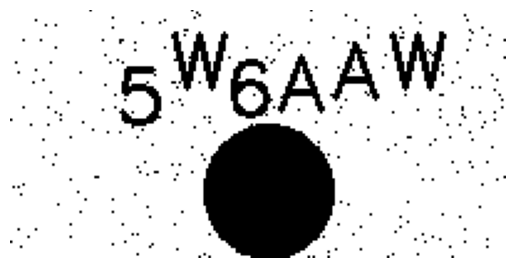

In [104]:
images, labels = next(iter(train_loader))

import matplotlib.pyplot as plt

idx = 0

plt.imshow(images[idx][0], cmap='gray')
plt.axis("off")

decoded = "".join(
    idx_to_char[i.item()]
    for i in labels[idx]
)

print("Label:", decoded)

In [105]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [106]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class CRNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(1,64),
            nn.MaxPool2d(2,2),

            ConvBlock(64,128),
            nn.MaxPool2d(2,2),

            ConvBlock(128,256),
            ConvBlock(256,256),
            nn.MaxPool2d((2,1),(2,1)),

            ConvBlock(256,512),
            ConvBlock(512,512),
            nn.MaxPool2d((2,1),(2,1))
        )

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.1
        )

        self.classifier = nn.Linear(512, num_classes)

        with torch.no_grad():
            self.classifier.bias[0] = -2.0

    def forward(self, x):

        x = self.cnn(x)

        x = x.mean(dim=2)

        x = x.permute(0,2,1)

        x,_ = self.rnn(x)

        x = self.classifier(x)

        return x

In [107]:
print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


In [108]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[0])

torch.Size([32, 1, 100, 200])
torch.Size([32, 6])
tensor([15, 27, 29, 23, 29, 31])


In [109]:
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

In [110]:
model = CRNN(
    num_classes=len(char_to_idx)+1
)

In [111]:
import torch.nn.functional as F

images, labels = next(iter(train_loader))

output = model(images)

output = F.log_softmax(
    output,
    dim=2
)

output = output.permute(1,0,2)

targets = labels.view(-1)

input_lengths = torch.full(
    (32,),
    50,
    dtype=torch.long
)

target_lengths = torch.full(
    (32,),
    6,
    dtype=torch.long
)

criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

loss = criterion(
    output,
    targets,
    input_lengths,
    target_lengths
)

print("Loss:", loss)

Loss: tensor(26.1396, grad_fn=<MeanBackward0>)


In [112]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [113]:
train_df_small = train_df.sample(
    n=128,
    random_state=42
)

print(len(train_df_small))

128


In [114]:
train_dataset_small = OCRDataset(
    train_df_small,
    train_path,
    char_to_idx
)

In [115]:
train_loader_small = DataLoader(
    train_dataset_small,
    batch_size=32,
    shuffle=True
)

In [116]:
model.train()

images, labels = next(iter(train_loader))

optimizer.zero_grad()

output = model(images)

output = F.log_softmax(
    output,
    dim=2
)

output = output.permute(1,0,2)

targets = labels.view(-1)

input_lengths = torch.full(
    (images.size(0),),
    50,
    dtype=torch.long
)

target_lengths = torch.full(
    (images.size(0),),
    6,
    dtype=torch.long
)

loss = criterion(
    output,
    targets,
    input_lengths,
    target_lengths
)

loss.backward()
nn.utils.clip_grad_norm_(
    model.parameters(),
    max_norm=5.0
)

optimizer.step()

print("Loss:", loss.item())

Loss: 26.122337341308594


In [117]:
model = CRNN(
    num_classes=len(char_to_idx)+1
)

print(model)

CRNN(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_run

In [118]:
import torch

print(torch.cuda.is_available())

False


In [119]:
print(len(train_loader))

563


In [120]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Create model
model = CRNN(
    num_classes=len(char_to_idx) + 1
)

# Loss
criterion = nn.CTCLoss(
    blank=0,
    zero_infinity=True
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Train
num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader_small:

        optimizer.zero_grad()

        output = model(images)

        output = F.log_softmax(
            output,
            dim=2
        )

        output = output.permute(1, 0, 2)

        targets = labels.view(-1)

        input_lengths = torch.full(
            (images.size(0),),
            output.size(0),
            dtype=torch.long
        )

        target_lengths = torch.full(
            (images.size(0),),
            6,
            dtype=torch.long
        )

        loss = criterion(
            output,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader_small)

    print(
        f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}"
    )

Epoch 1/30 | Loss: 25.7238
Epoch 2/30 | Loss: 23.1885
Epoch 3/30 | Loss: 21.7559
Epoch 4/30 | Loss: 20.6684
Epoch 5/30 | Loss: 18.8864
Epoch 6/30 | Loss: 13.8067
Epoch 7/30 | Loss: 6.3198
Epoch 8/30 | Loss: 4.3568
Epoch 9/30 | Loss: 3.9440
Epoch 10/30 | Loss: 3.7533
Epoch 11/30 | Loss: 3.7002
Epoch 12/30 | Loss: 3.6845
Epoch 13/30 | Loss: 3.6723
Epoch 14/30 | Loss: 3.6690
Epoch 15/30 | Loss: 3.6583
Epoch 16/30 | Loss: 3.6509
Epoch 17/30 | Loss: 3.6430
Epoch 18/30 | Loss: 3.6356
Epoch 19/30 | Loss: 3.6272
Epoch 20/30 | Loss: 3.6222
Epoch 21/30 | Loss: 3.6144
Epoch 22/30 | Loss: 3.6077
Epoch 23/30 | Loss: 3.5992
Epoch 24/30 | Loss: 3.5942
Epoch 25/30 | Loss: 3.5890
Epoch 26/30 | Loss: 3.5796
Epoch 27/30 | Loss: 3.5701
Epoch 28/30 | Loss: 3.5588
Epoch 29/30 | Loss: 3.5491
Epoch 30/30 | Loss: 3.5397


In [126]:
def decode_prediction(pred, idx_to_char):

    pred = pred.argmax(dim=1).cpu().numpy()

    decoded = []
    prev = -1

    for p in pred:

        if p != prev and p != 0:
            decoded.append(idx_to_char[p])

        prev = p

    return "".join(decoded)

In [134]:
model.eval()

images, labels = next(iter(train_loader_small))

with torch.no_grad():
    output = model(images)

for i in range(10):

    pred_text = decode_prediction(
        output[i],
        idx_to_char
    )

    actual_text = "".join(
        idx_to_char[x.item()]
        for x in labels[i]
    )

    print("Actual   :", actual_text)
    print("Predicted:", pred_text)
    print()

Actual   : 8WMGF7
Predicted: QN6EZY

Actual   : 9TTHVU
Predicted: Y8QN6EZY

Actual   : MB46T7
Predicted: Y8Q6ZY

Actual   : TCG69Z
Predicted: 8Q6EY

Actual   : P8D4FX
Predicted: Y8Q6ZEY

Actual   : 2SDKY8
Predicted: Y8Q6EZY

Actual   : 8QGHSY
Predicted: Q6ZEZY

Actual   : K6SKR7
Predicted: Y8T9Q8Q6EZY

Actual   : DBFBST
Predicted: Y8QN6

Actual   : T75ZHT
Predicted: Y8Q6EZY



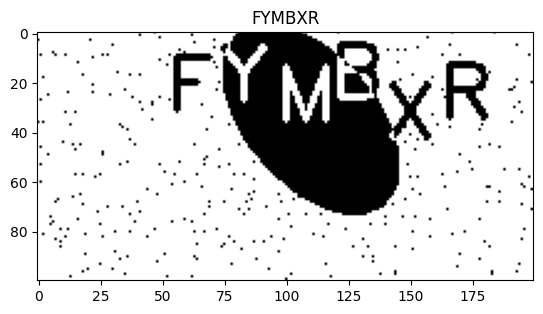

In [135]:
import matplotlib.pyplot as plt

image, label = train_dataset_small[0]

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    "".join(
        idx_to_char[i.item()]
        for i in label
    )
)

plt.show()

In [128]:
model.eval()

images, labels = next(iter(val_loader))

with torch.no_grad():
    output = model(images)

pred = output[0].argmax(dim=1)

print(torch.unique(pred))

tensor([ 0,  7,  8, 20, 22, 25, 30])


In [129]:
model.eval()

images, labels = next(iter(val_loader))

with torch.no_grad():
    output = model(images)

print(output.shape)

probs = torch.softmax(output[0, 0], dim=0)

print("Argmax:", torch.argmax(probs))
print("Top 5 probs:", torch.topk(probs, 5))

torch.Size([32, 50, 32])
Argmax: tensor(30)
Top 5 probs: torch.return_types.topk(
values=tensor([0.0384, 0.0370, 0.0359, 0.0352, 0.0350]),
indices=tensor([30, 13, 31,  8, 27]))
